In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
DATA_DIR = "data/nutrition5k"
IMAGE_DIR = os.path.join(DATA_DIR, "imagery", "realsense_overhead")
NUTRITION_CSV = os.path.join(DATA_DIR, "dish_nutrition_values.csv")

print("Data folder exists:", os.path.exists(DATA_DIR))
print("Image folder exists:", os.path.exists(IMAGE_DIR))
print("Nutrition CSV exists:", os.path.exists(NUTRITION_CSV))

Data folder exists: True
Image folder exists: True
Nutrition CSV exists: True


In [6]:
import pandas as pd

nutrition_df = pd.read_csv(NUTRITION_CSV)

print("Shape:", nutrition_df.shape)
nutrition_df.head()

Shape: (4768, 6)


,dish_id,calories,mass,fat,carb,protein
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000


In [7]:
nutrition_df.columns

Index(['dish_id', 'calories', 'mass', 'fat', 'carb', 'protein'], dtype='str')

In [8]:
image_files = []

for root, dirs, files in os.walk(IMAGE_DIR):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Number of images found:", len(image_files))

for path in image_files[:10]:
    print(path)

Number of images found: 10419
data/nutrition5k/imagery/realsense_overhead/dish_1565379827/rgb.png
data/nutrition5k/imagery/realsense_overhead/dish_1565379827/depth_raw.png
data/nutrition5k/imagery/realsense_overhead/dish_1565379827/depth_color.png
data/nutrition5k/imagery/realsense_overhead/dish_1563468269/rgb.png
data/nutrition5k/imagery/realsense_overhead/dish_1563468269/depth_raw.png
data/nutrition5k/imagery/realsense_overhead/dish_1563468269/depth_color.png
data/nutrition5k/imagery/realsense_overhead/dish_1563389786/rgb.png
data/nutrition5k/imagery/realsense_overhead/dish_1563389786/depth_raw.png
data/nutrition5k/imagery/realsense_overhead/dish_1563389786/depth_color.png
data/nutrition5k/imagery/realsense_overhead/dish_1561662458/rgb.png


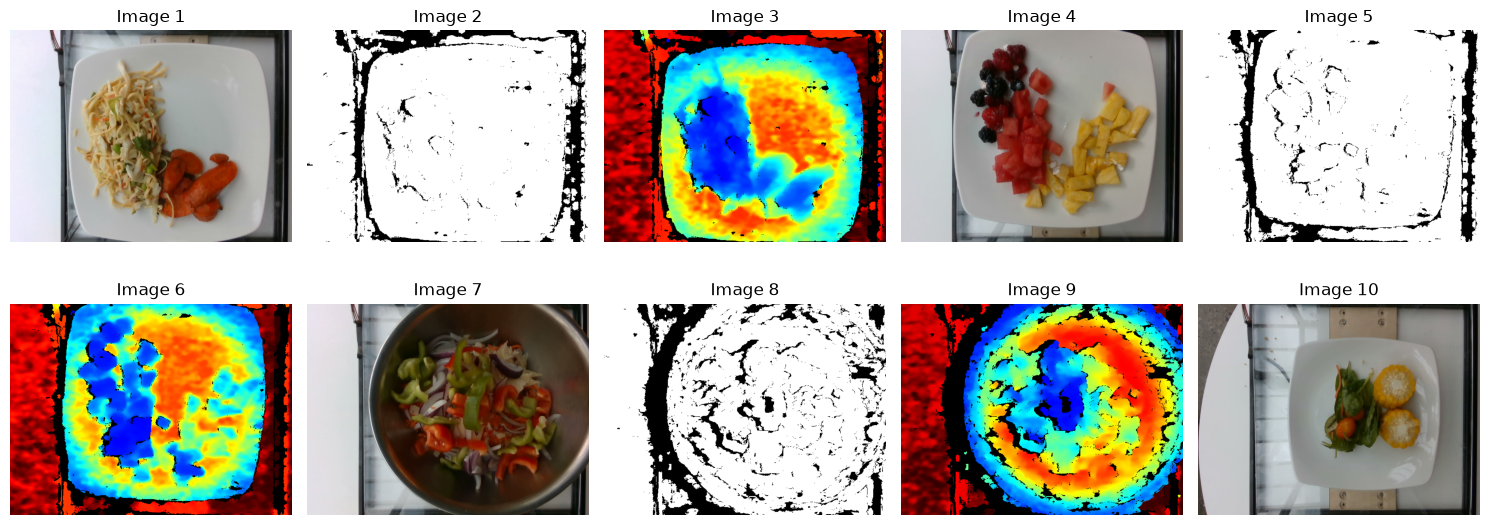

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

for i, img_path in enumerate(image_files[:10]):
    img = Image.open(img_path).convert("RGB")
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {i + 1}")

plt.tight_layout()
plt.show()

In [10]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

img = Image.open(image_files[0]).convert("RGB")
img_tensor = transform(img)

print(type(img_tensor))
print(img_tensor.shape)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])


In [ ]:
## Initial Data Exploration Notes

The Nutrition5k dataset loaded successfully. The notebook was able to access the nutrition CSV file and display the first 10 food images from the realsense_overhead folder. This confirms that the dataset contains usable image data for a computer vision model.

The PyTorch transform also successfully resized an image and converted it into a tensor with shape [3, 224, 224], which means the image is now in the correct format for CNN training. For the next step, we need to connect each image to its matching calorie label from dish_nutrition_values.csv.